<a href="https://colab.research.google.com/github/bu11ymaguire/2025-Statistics-Analyze-Contest/blob/main/26_01_02_vol1_binary_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN 이진분류 - 고양이, 강아지 데이터
- 로컬 이미지를 로딩해서 학습

In [37]:
import cupy as cp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
import keras

In [38]:
import random
seed = 42

random.seed(42)
np.random.seed(42)
cp.random.seed(42)
tf.random.set_seed(42)

np.set_printoptions(precision=4,linewidth=200,suppress=True)

#데이터 준비

In [4]:
!gdown https://drive.google.com/uc?id=1dC-Kso5FonYWtbxtJnJ8_dxO_Jlo8weR

Downloading...
From (original): https://drive.google.com/uc?id=1dC-Kso5FonYWtbxtJnJ8_dxO_Jlo8weR
From (redirected): https://drive.google.com/uc?id=1dC-Kso5FonYWtbxtJnJ8_dxO_Jlo8weR&confirm=t&uuid=bdbfc804-69f3-42da-a6ef-1054a37c7a64
To: /content/cats_and_dogs.zip
100% 68.6M/68.6M [00:00<00:00, 70.8MB/s]


In [5]:
!unzip cats_and_dogs.zip

Archive:  cats_and_dogs.zip
   creating: cats_and_dogs/
   creating: cats_and_dogs/test/
   creating: cats_and_dogs/test/cats/
  inflating: cats_and_dogs/test/cats/cat.2300.jpg  
  inflating: cats_and_dogs/test/cats/cat.2301.jpg  
  inflating: cats_and_dogs/test/cats/cat.2302.jpg  
  inflating: cats_and_dogs/test/cats/cat.2303.jpg  
  inflating: cats_and_dogs/test/cats/cat.2304.jpg  
  inflating: cats_and_dogs/test/cats/cat.2305.jpg  
  inflating: cats_and_dogs/test/cats/cat.2306.jpg  
  inflating: cats_and_dogs/test/cats/cat.2307.jpg  
  inflating: cats_and_dogs/test/cats/cat.2308.jpg  
  inflating: cats_and_dogs/test/cats/cat.2309.jpg  
  inflating: cats_and_dogs/test/cats/cat.2310.jpg  
  inflating: cats_and_dogs/test/cats/cat.2311.jpg  
  inflating: cats_and_dogs/test/cats/cat.2312.jpg  
  inflating: cats_and_dogs/test/cats/cat.2313.jpg  
  inflating: cats_and_dogs/test/cats/cat.2314.jpg  
  inflating: cats_and_dogs/test/cats/cat.2315.jpg  
  inflating: cats_and_dogs/test/cats/cat.

#데이터 로드

In [39]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
DATA_DIR = "/content/cats_and_dogs"

In [40]:
train_ds = keras.utils.image_dataset_from_directory(
    directory=DATA_DIR + "/train", labels = 'inferred', label_mode ='int',
    image_size = (IMG_HEIGHT, IMG_WIDTH), batch_size = BATCH_SIZE,
    shuffle = True, seed = seed
)

Found 2600 files belonging to 2 classes.


In [41]:
class_name = train_ds.class_names
print(class_name)

['cats', 'dogs']


In [42]:
val_ds = keras.utils.image_dataset_from_directory(
    directory=DATA_DIR + "/test", labels = 'inferred', label_mode ='int',
    image_size = (IMG_HEIGHT, IMG_WIDTH), batch_size = BATCH_SIZE,
    shuffle = True, seed = seed
)

Found 400 files belonging to 2 classes.


#EDA

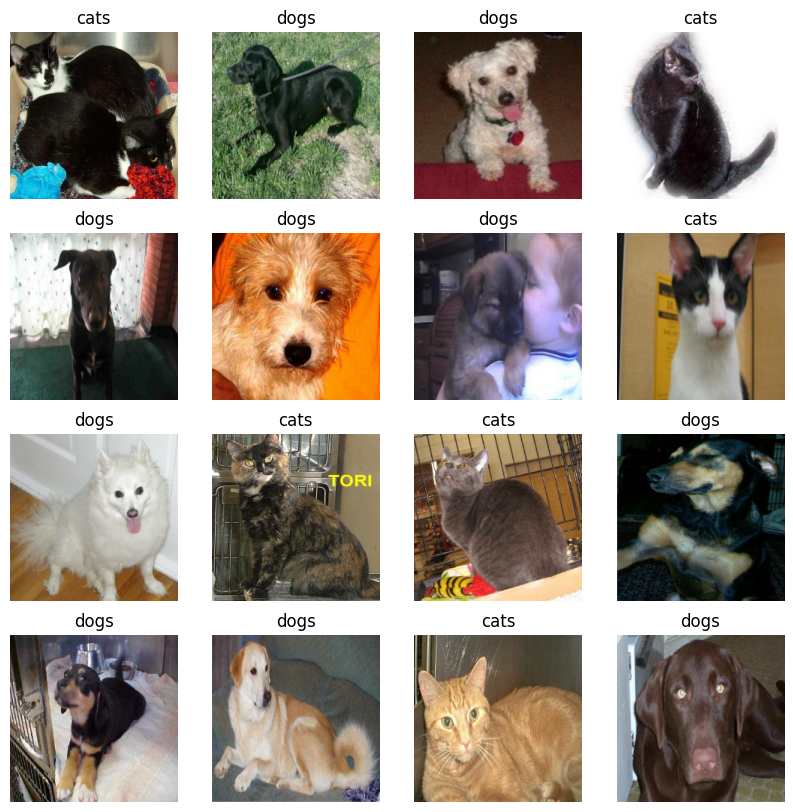

In [43]:
for images, labels in train_ds.take(1):
  break

plt.figure(figsize=(10,10))

for i in range(16):
  ax = plt.subplot(4,4,i+1)
  plt.imshow(images[i].numpy().astype(np.uint8))
  plt.axis("off")
  labels_index = labels[i].numpy()
  plt.title(class_name[labels_index])

plt.show()

#데이터 전처리

### 스케일링(정규화)

In [44]:
normalization_layer = keras.layers.Rescaling(1/255.)

def preprocess_image(x, y):
  x = tf.image.resize(x, [IMG_HEIGHT, IMG_WIDTH])
  x = normalization_layer(x)
  return x, y

In [45]:
train_ds = train_ds.map(preprocess_image)
val_ds = val_ds.map(preprocess_image)

### 데이터 로더 최적화

In [46]:
train_ds = train_ds.cache().prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size = tf.data.AUTOTUNE)

모델

In [47]:
base = keras.applications.VGG16(
    input_shape = (IMG_HEIGHT, IMG_WIDTH, 3),
    weights = "imagenet", include_top = False,
)

base.trainable = False

In [48]:
base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [49]:
from keras import layers

def build_model():
  model = keras.Sequential([
      base,
      layers.Flatten(),
      layers.Dense(32, activation = 'relu'),
      layers.Dropout(0.5),
      # layers.Dense(1, activation = 'sigmoid')
      layers.Dense(2, activation = 'softmax')
  ])

  return model

In [50]:
model = build_model()

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │       802,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,517,602 (59.19 MB)

 Trainable params: 802,914 (3.06 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 컴파일

In [51]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

#학습

In [52]:
EPOCH = 3

history = model.fit(train_ds,validation_data = val_ds, epochs = EPOCH )

Epoch 1/3
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.6480 - loss: 0.6349 - val_accuracy: 0.9050 - val_loss: 0.2943
Epoch 2/3
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8484 - loss: 0.3546 - val_accuracy: 0.9100 - val_loss: 0.2406
Epoch 3/3
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8783 - loss: 0.3180 - val_accuracy: 0.9025 - val_loss: 0.2559


#학습곡선

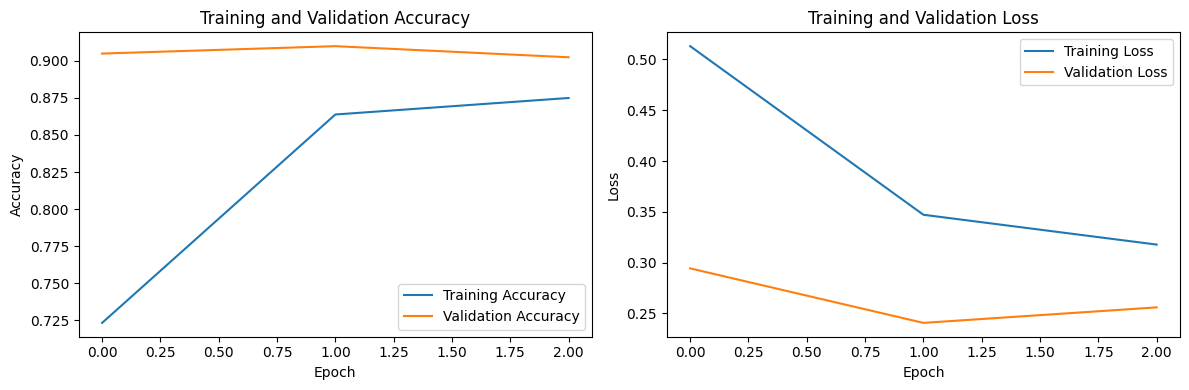

In [55]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

#테스트

In [53]:
# /content/cats_and_dogs/test/cats/cat.2341.jpg
import PIL

image = PIL.Image.open("/content/cats_and_dogs/test/cats/cat.2341.jpg")
image = np.array(image)

In [54]:
image.shape

(417, 299, 3)

In [57]:
x_test = np.expand_dims(image, axis = 0)
x_test.shape

(1, 417, 299, 3)

In [58]:
y_test = np.array([[0]])
y_test.shape

(1, 1)

In [61]:
t2st_ds = tf.data.Dataset.from_tensor_slices((x_test,y_test))

In [65]:
t2st_ds = t2st_ds.map(preprocess_image) # preprocess_image 적용 후 t2st_ds 업데이트
t2st__ = t2st_ds.batch(1)

In [66]:
y_pred = model.predict(t2st__)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[0.4758, 0.5242]], dtype=float32)

In [69]:
np.argmax(y_pred, axis = 1)

array([1])

In [71]:
np.argmax(y_test, axis = 1) # t2st__ 대신 y_test 사용

array([0])

##TBD